# Section 1 — Fund Performance
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

> ### ⚠️ Mandatory caveat — what "performance" means here
> **There is NO NAV / unit-price / investment-return series in the data.** We cannot and do not measure investment performance (alpha, total return, Sharpe). Everything in this section defines fund "performance" as **flow, retention, and engagement** — i.e. the asset-gathering and asset-retention behaviour of each fund, not how well the underlying portfolio performed. `Investment Value (At Market)` is treated as a current **book/AUM** figure, never as a return.

**What the manager decides Monday:** which funds to defend (leakage), which to grow (net inflow + persistency), and where the SIP base is silently eroding.

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import _common as C
from lifelines import KaplanMeierFitter

defs = C.load_defs()
C.set_style()
SEC = 'section1'
AS_OF = C.AS_OF

acc = C.load_accounts()
mf  = C.load_monthly_flows()
tx  = C.load_transactions()
FUNDS = defs['funds']
SHORT = C.FUND_SHORT
COL = C.FUND_COLORS
metrics = {}   # headline numbers persisted for Gate 2
print('accounts', acc.shape, '| monthly_flows', mf.shape, '| tx', tx.shape)
print('AS_OF', AS_OF.date(), '| total AUM (book)', C.taka(acc.investment_value_market.sum()))

accounts (12229, 48) | monthly_flows (212796, 11) | tx (231248, 13)
AS_OF 2026-05-31 | total AUM (book) ৳301.6 Cr


## 1.1 Fund scorecard
One row per fund: scale (accounts, AUM), status mix, leakage rates (closure & discontinuation, strict-churn headline + broad sensitivity), retention, and net flow **both value-weighted (Taka) and account-weighted**. Rate denominators exclude the 2 suspended accounts per `definitions.yaml`.

In [2]:
# rate-eligible frame (suspended excluded from denominators)
acc_rate = C.rate_denominator(acc)

# value-weighted net flow per fund from monthly_flows (Purchase - Surrender, dividends excluded)
flow_fund = mf.groupby('fund').agg(
    purchase=('purchase_amount','sum'),
    surrender=('surrender_amount','sum'),
    net_flow=('net_flow','sum')).reindex(FUNDS)

# account-weighted net flow = net flow per account that ever transacted in the fund
acct_per_fund = acc.groupby('fund').size().reindex(FUNDS)

rows = []
for f in FUNDS:
    sub = acc[acc.fund==f]
    subr = acc_rate[acc_rate.fund==f]
    r = C.status_rates(subr)
    rows.append(dict(
        fund=f,
        accounts=len(sub),
        customers=sub.mobile_no.nunique(),
        aum_book=sub.investment_value_market.sum(),
        onboarding_capital=sub.onboarding_amount.sum(),
        sip_share=(sub.is_sip).mean(),
        active=r['retention'], closure=r['closure'], discontinuation=r['discontinuation'],
        churn_strict=r['churn_strict'], churn_broad=r['churn_broad'],
        net_flow_value=flow_fund.loc[f,'net_flow'],
        net_flow_per_acct=flow_fund.loc[f,'net_flow']/acct_per_fund[f],
    ))
scorecard = pd.DataFrame(rows).set_index('fund')
disp = scorecard.copy()
for c in ['sip_share','active','closure','discontinuation','churn_strict','churn_broad']:
    disp[c] = (disp[c]*100).round(1)
for c in ['aum_book','onboarding_capital','net_flow_value','net_flow_per_acct']:
    disp[c] = disp[c].round(0)
C.save_table(scorecard, SEC, 'fund_scorecard')
metrics['fund_scorecard'] = scorecard.reset_index().to_dict('records')
metrics['total_aum_book'] = float(acc.investment_value_market.sum())
metrics['total_net_flow_value'] = float(mf.net_flow.sum())
disp

,accounts,customers,aum_book,onboarding_capital,sip_share,active,closure,discontinuation,churn_strict,churn_broad,net_flow_value,net_flow_per_acct
fund,,,,,,,,,,,,
Apex Fixed Income Fund,3221,2688,992089129.0,883595000,71.5,69.6,13.3,2.7,16.0,30.4,817308127.0,253744.0
Apex Shariah Growth Fund,3086,2530,786576255.0,330697000,97.6,60.8,31.2,6.3,37.5,39.2,743086501.0,240793.0
Apex Balanced Opportunity Fund,2143,1977,366668800.0,426559000,72.7,45.1,28.5,5.2,33.7,54.9,251398256.0,117311.0
Apex Capital Growth Fund,3779,3330,870806237.0,252430000,94.1,48.7,39.7,7.6,47.2,51.3,680845321.0,180165.0


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


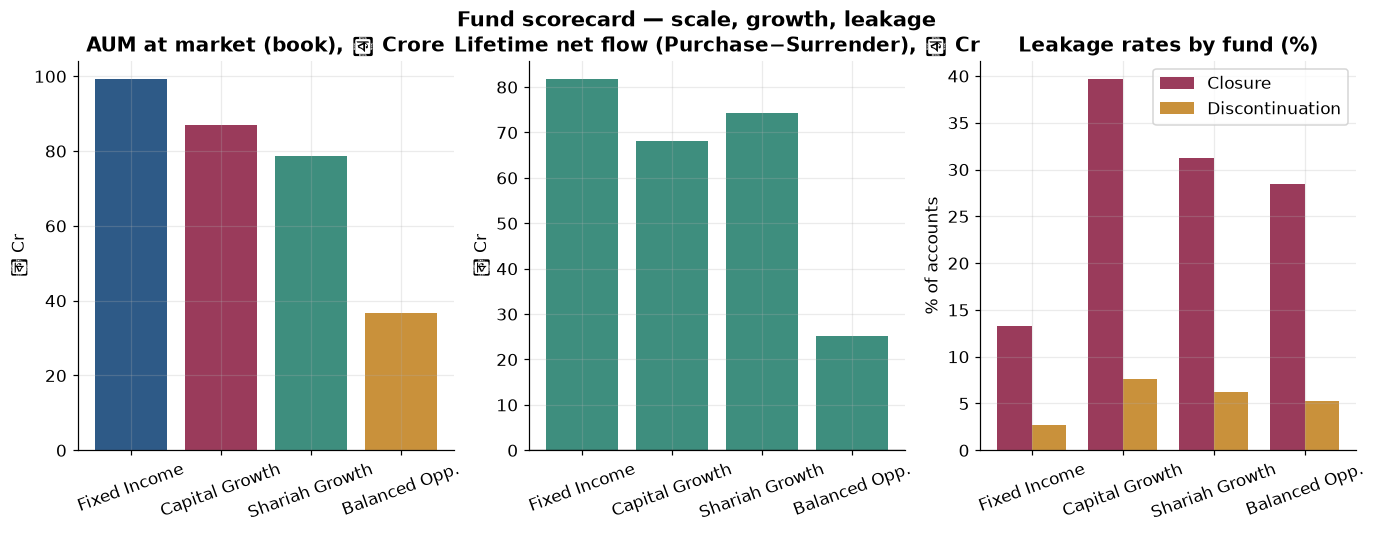

In [3]:
# Figure: AUM (book) and net flow value per fund, with churn overlay
fig, axes = plt.subplots(1, 3, figsize=(15,4.6))
order = scorecard.sort_values('aum_book', ascending=False).index
x = [SHORT[f] for f in order]; cols=[COL[f] for f in order]
axes[0].bar(x, [scorecard.loc[f,'aum_book']/1e7 for f in order], color=cols)
axes[0].set_title('AUM at market (book), ৳ Crore'); axes[0].set_ylabel('৳ Cr')
axes[0].tick_params(axis='x', rotation=20)
nf=[scorecard.loc[f,'net_flow_value']/1e7 for f in order]
axes[1].bar(x, nf, color=['#3E8E7E' if v>=0 else '#9A3B5B' for v in nf])
axes[1].axhline(0,color='k',lw=.8); axes[1].set_title('Lifetime net flow (Purchase−Surrender), ৳ Cr')
axes[1].set_ylabel('৳ Cr'); axes[1].tick_params(axis='x', rotation=20)
w=0.38; idx=np.arange(len(order))
axes[2].bar(idx-w/2,[scorecard.loc[f,'closure']*100 for f in order],w,label='Closure',color='#9A3B5B')
axes[2].bar(idx+w/2,[scorecard.loc[f,'discontinuation']*100 for f in order],w,label='Discontinuation',color='#C9913B')
axes[2].set_xticks(idx); axes[2].set_xticklabels(x, rotation=20)
axes[2].set_title('Leakage rates by fund (%)'); axes[2].set_ylabel('% of accounts'); axes[2].legend()
fig.suptitle('Fund scorecard — scale, growth, leakage', fontsize=14, fontweight='bold')
C.savefig(fig, SEC, '01_fund_scorecard'); plt.show()

## 1.2 SIP persistency — the core asset
For a SIP-first book, the asset is not the sign-up — it is the **stream of installments that keeps arriving**. We measure, per SIP account, **installments actually paid vs. expected** over its active window (onboarding → min(stop, planned tenor, as-of)), then trace the **persistency-decay curve**: of accounts whose schedule reaches month *k*, what share actually paid in month *k*. Shown by fund and by onboarding vintage.

In [4]:
# Paid months per SIP account = distinct months with a purchase in monthly_flows
sip = acc[acc.is_sip].copy()
paid = (mf[mf.purchase_amount>0]
        .assign(m=lambda d: d.transaction_month)
        .groupby('account_number')['m'].nunique())
sip['paid_months'] = sip.registration_no.map(paid).fillna(0).astype(int)

# expected months: calendar months from onboarding to end-of-window, capped at planned tenor
def end_window(row):
    ends = [AS_OF]
    if pd.notna(row.account_closing_date): ends.append(row.account_closing_date)
    if pd.notna(row.sip_discontinuation_date): ends.append(row.sip_discontinuation_date)
    return min(ends)
sip['win_end'] = sip.apply(end_window, axis=1)
elapsed = ((sip.win_end.dt.year - sip.first_purchase_date.dt.year)*12
           + (sip.win_end.dt.month - sip.first_purchase_date.dt.month) + 1).clip(lower=0)
tenor = sip.tenor_in_month.replace(0, np.nan)
sip['expected_months'] = np.minimum(elapsed, tenor.fillna(elapsed)).clip(lower=1).astype(int)
sip['persistency'] = (sip.paid_months / sip.expected_months).clip(upper=1.0)

pers_by_fund = sip.groupby('fund').agg(
    sip_accounts=('persistency','size'),
    mean_persistency=('persistency','mean'),
    median_persistency=('persistency','median'),
    paid=('paid_months','sum'), expected=('expected_months','sum')).reindex(FUNDS)
pers_by_fund['weighted_persistency'] = pers_by_fund.paid/pers_by_fund.expected
C.save_table(pers_by_fund, SEC, 'sip_persistency_by_fund')
metrics['sip_persistency_by_fund'] = pers_by_fund.reset_index().to_dict('records')
metrics['sip_persistency_overall'] = float(sip.paid_months.sum()/sip.expected_months.sum())
print('Overall SIP persistency (paid/expected installments):', round(metrics['sip_persistency_overall'],3))
pers_by_fund.round(3)

Overall SIP persistency (paid/expected installments): 0.879


,sip_accounts,mean_persistency,median_persistency,paid,expected,weighted_persistency
fund,,,,,,
Apex Fixed Income Fund,2303,0.845,0.909,26819,30349,0.884
Apex Shariah Growth Fund,3012,0.847,0.917,59970,67667,0.886
Apex Balanced Opportunity Fund,1558,0.771,0.833,27843,33062,0.842
Apex Capital Growth Fund,3555,0.850,0.926,86670,97814,0.886


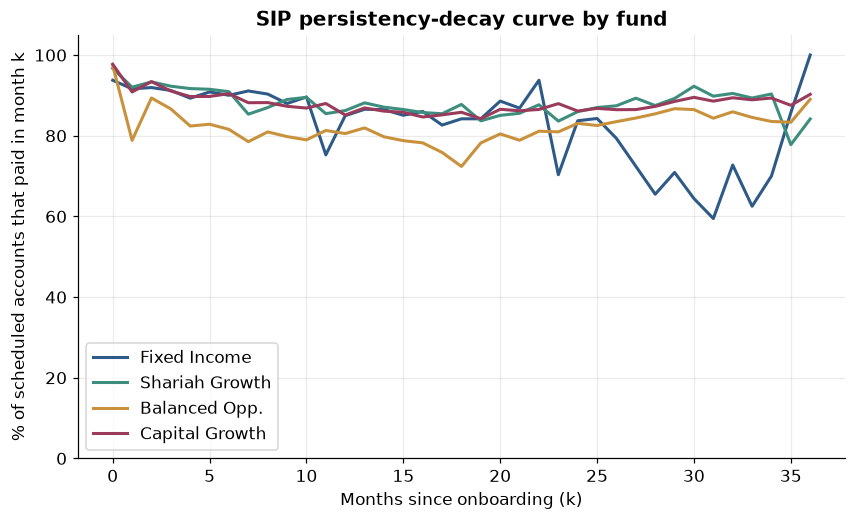

month_k,0,6,12,24,36
fund,,,,,
Apex Balanced Opportunity Fund,97.4,81.6,80.5,83.1,89.0
Apex Capital Growth Fund,97.7,90.4,85.1,86.1,90.3
Apex Fixed Income Fund,93.7,90.0,85.0,83.7,100.0
Apex Shariah Growth Fund,96.7,90.9,86.2,86.0,84.2


In [5]:
# Persistency-decay curve: share of SIP accounts still paying at month k since onboarding
mfp = mf[mf.purchase_amount>0].merge(
    sip[['registration_no','first_purchase_date','expected_months']],
    left_on='account_number', right_on='registration_no', how='inner')  # fund comes from mf
tm = pd.PeriodIndex(mfp.transaction_month, freq='M').to_timestamp()
fp = mfp.first_purchase_date.dt.to_period('M').dt.to_timestamp()
mfp['k'] = ((tm.year-fp.dt.year)*12 + (tm.month-fp.dt.month))
paid_k = mfp[(mfp.k>=0)&(mfp.k<=36)].groupby(['fund','k']).account_number.nunique()

# denominator at month k = SIP accounts whose expected window reaches >= k
def reaching(fund, k):
    s = sip[sip.fund==fund]; return int((s.expected_months-1 >= k).sum())
fig, ax = plt.subplots(figsize=(9,5))
decay_tbl = []
for f in FUNDS:
    ks = range(0,37)
    y = [ (paid_k.get((f,k),0)/reaching(f,k) if reaching(f,k)>0 else np.nan) for k in ks ]
    ax.plot(list(ks), [v*100 if v==v else np.nan for v in y], marker='', lw=2, color=COL[f], label=SHORT[f])
    for k in [0,6,12,24,36]:
        decay_tbl.append(dict(fund=f, month_k=k, pct_paying=(y[k]*100 if y[k]==y[k] else np.nan)))
ax.set_xlabel('Months since onboarding (k)'); ax.set_ylabel('% of scheduled accounts that paid in month k')
ax.set_title('SIP persistency-decay curve by fund'); ax.legend(); ax.set_ylim(0,105)
C.savefig(fig, SEC, '02_sip_persistency_decay'); plt.show()
decay = pd.DataFrame(decay_tbl); C.save_table(decay, SEC, 'sip_persistency_decay', index=False)
metrics['sip_decay_checkpoints'] = decay.to_dict('records')
decay.pivot(index='fund', columns='month_k', values='pct_paying').round(1)

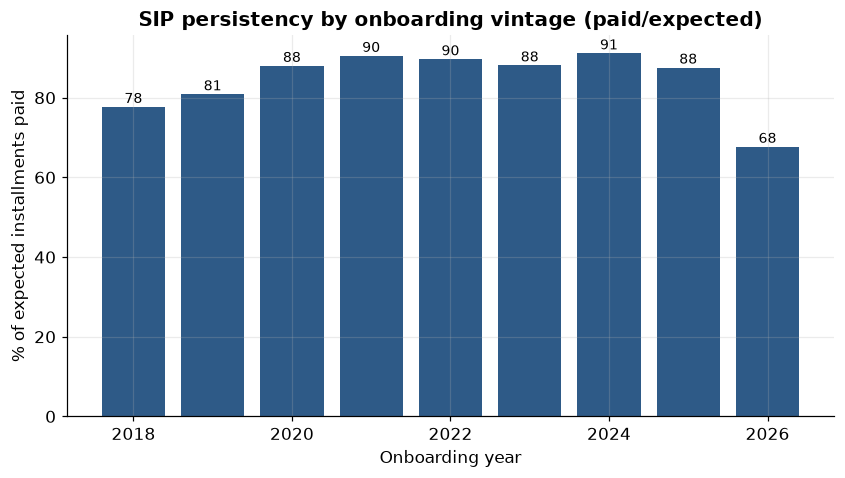

,sip_accounts,paid,expected,weighted_persistency
onboarding_year,,,,
2018,269,6762,8706,0.777
2019,422,12228,15125,0.808
2020,132,4977,5658,0.880
2021,865,29473,32577,0.905
2022,1929,55550,61975,0.896
2023,1765,41647,47277,0.881
2024,1411,25310,27777,0.911
2025,2524,22871,26126,0.875
2026,1111,2484,3671,0.677


In [6]:
# Persistency by onboarding vintage (year) -- is newer money stickier or leakier?
pers_vint = sip.groupby('onboarding_year').agg(
    sip_accounts=('persistency','size'), paid=('paid_months','sum'),
    expected=('expected_months','sum'))
pers_vint['weighted_persistency'] = pers_vint.paid/pers_vint.expected
fig, ax = plt.subplots(figsize=(9,4.5))
yy=pers_vint.index.astype(int)
ax.bar(yy, pers_vint.weighted_persistency*100, color='#2E5A87')
ax.set_title('SIP persistency by onboarding vintage (paid/expected)')
ax.set_ylabel('% of expected installments paid'); ax.set_xlabel('Onboarding year')
for x_,v in zip(yy, pers_vint.weighted_persistency*100): ax.text(x_, v+1, f'{v:.0f}', ha='center', fontsize=9)
C.savefig(fig, SEC, '03_sip_persistency_vintage'); plt.show()
C.save_table(pers_vint, SEC, 'sip_persistency_by_vintage')
pers_vint.round(3)

## 1.3 Cohort / vintage survival (Kaplan–Meier)
Snapshots hide *when* accounts die. We build a survival model where the **event = strict churn** (closed **or** discontinued) and **duration = months from first purchase to the event**, censoring still-alive accounts at as-of. Curves are split by onboarding-year cohort so we can see whether retention is structurally worsening for newer vintages.

events (strict churn): 4174 | censored: 8053 | reclassified missing-date events: 4


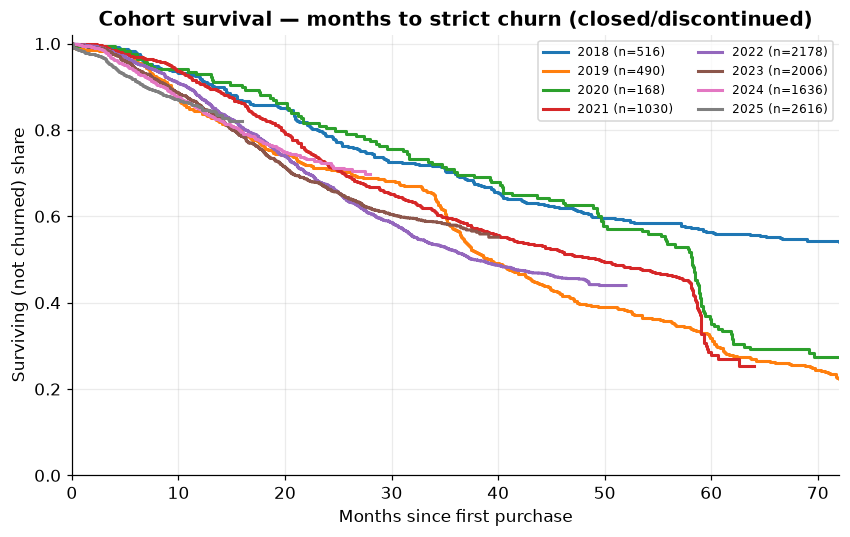

,surv_12m,surv_24m,surv_36m
2018,91.9,78.7,69.8
2019,84.3,71.0,56.7
2020,92.9,80.4,70.2
2021,90.9,72.0,59.3
2022,87.6,67.2,52.0
2023,85.7,66.5,57.9
2024,84.8,72.4,69.9
2025,85.4,82.1,82.1


In [7]:
surv = acc[~acc.excluded_from_rates].copy()
# duration in months to event (strict churn) or censor (as-of)
days_event = np.where(surv.status.eq('closed'), surv.days_to_closure,
             np.where(surv.status.eq('discontinued'), surv.days_to_discontinuation, np.nan))
dur_event = pd.Series(days_event, index=surv.index)/30.44
dur_censor = surv.tenure_to_date_months.astype(float)
surv['event'] = surv.churn_strict.astype(int)
surv['duration'] = np.where(surv.event==1, dur_event, dur_censor)
# 3 closed w/o closing date + 1 disc w/o date -> event date missing: censor them instead (flagged)
missing_evt = surv.event.eq(1) & surv.duration.isna()
surv.loc[missing_evt, 'duration'] = surv.loc[missing_evt,'tenure_to_date_months'].astype(float)
surv.loc[missing_evt, 'event'] = 0
surv['duration'] = surv.duration.astype(float).clip(lower=0.1)
print('events (strict churn):', int(surv.event.sum()), '| censored:', int((surv.event==0).sum()),
      '| reclassified missing-date events:', int(missing_evt.sum()))

fig, ax = plt.subplots(figsize=(9,5.2))
km = KaplanMeierFitter()
surv_at = {}
for yr in sorted(surv.onboarding_year.dropna().unique()):
    if yr < 2018 or yr > 2025: continue   # tiny / right-truncated tails
    s = surv[surv.onboarding_year==yr]
    if len(s) < 100: continue
    km.fit(s.duration, s.event, label=f'{int(yr)} (n={len(s)})')
    km.plot_survival_function(ax=ax, ci_show=False, lw=2)
    surv_at[int(yr)] = {m: float(km.survival_function_at_times(m).iloc[0]) for m in [12,24,36]}
ax.set_title('Cohort survival — months to strict churn (closed/discontinued)')
ax.set_xlabel('Months since first purchase'); ax.set_ylabel('Surviving (not churned) share')
ax.set_xlim(0,72); ax.set_ylim(0,1.02); ax.legend(fontsize=8, ncol=2)
C.savefig(fig, SEC, '04_cohort_survival_km'); plt.show()
surv_tbl = pd.DataFrame(surv_at).T[ [12,24,36] ] if surv_at else pd.DataFrame()
surv_tbl.columns = ['surv_12m','surv_24m','surv_36m']
C.save_table(surv_tbl, SEC, 'cohort_survival_km')
metrics['cohort_survival_km'] = surv_tbl.reset_index(names='onboarding_year').to_dict('records')
(surv_tbl*100).round(1)

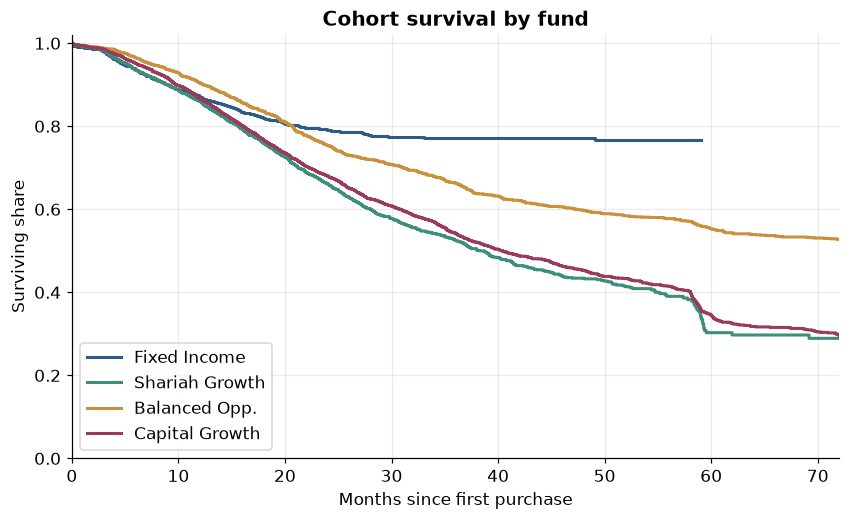

,surv_12m,surv_24m,surv_36m
Apex Fixed Income Fund,87.2,79.1,77.2
Apex Shariah Growth Fund,86.0,66.1,52.6
Apex Balanced Opportunity Fund,90.4,75.4,66.3
Apex Capital Growth Fund,86.7,68.0,54.2


In [8]:
# KM survival by FUND (which fund retains money longest)
fig, ax = plt.subplots(figsize=(9,5))
fund_surv = {}
for f in FUNDS:
    s = surv[surv.fund==f]
    km.fit(s.duration, s.event, label=SHORT[f])
    km.plot_survival_function(ax=ax, ci_show=False, lw=2, color=COL[f])
    fund_surv[f] = {m: float(km.survival_function_at_times(m).iloc[0]) for m in [12,24,36]}
ax.set_title('Cohort survival by fund'); ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Surviving share'); ax.set_xlim(0,72); ax.set_ylim(0,1.02); ax.legend()
C.savefig(fig, SEC, '05_cohort_survival_by_fund'); plt.show()
fund_surv_tbl = pd.DataFrame(fund_surv).T; fund_surv_tbl.columns=['surv_12m','surv_24m','surv_36m']
C.save_table(fund_surv_tbl, SEC, 'cohort_survival_by_fund')
metrics['fund_survival'] = fund_surv_tbl.reset_index(names='fund').to_dict('records')
(fund_surv_tbl*100).round(1)

## 1.4 Book-value multiple & surrender timing
**Book multiple** = current AUM (at market) ÷ capital actually put in. With no NAV series this is a crude *book* ratio (retained value vs. gross contributions), **not a return** — but it flags which funds are net accretive vs. net drained. We also test whether **surrenders spike right after dividend distributions** (Jul/Jan) — a redemption-trigger pattern the manager can pre-empt.

In [9]:
# Book multiple: AUM at market vs net invested capital (cumulative Purchase - Surrender) and vs onboarding capital
mult = scorecard[['aum_book','onboarding_capital','net_flow_value']].copy()
mult['mult_vs_onboarding'] = mult.aum_book/mult.onboarding_capital
mult['mult_vs_netinvested'] = mult.aum_book/mult.net_flow_value
C.save_table(mult, SEC, 'book_multiple_by_fund')
metrics['book_multiple'] = mult.reset_index().to_dict('records')

# Surrender timing vs dividend months
tx2 = tx.copy(); tx2['ym']=tx2.transaction_date.dt.to_period('M').astype(str); tx2['mo']=tx2.transaction_date.dt.month
div_months = sorted(tx2[tx2.transaction_type=='Dividend'].mo.value_counts().index[:2].tolist())
after = [(m % 12)+1 for m in div_months]
sur = tx2[tx2.transaction_type=='Surrender']
in_div = sur.mo.isin(div_months).mean(); in_after = sur.mo.isin(after).mean()
in_div_val = sur[sur.mo.isin(div_months)].amount.sum()/sur.amount.sum()
base = 2/12
metrics['surrender_timing'] = dict(div_months=div_months, after_months=after,
    surrender_share_in_div_months=float(in_div), surrender_value_share_in_div_months=float(in_div_val),
    surrender_share_month_after=float(in_after), uniform_baseline=base)
print('Dividend months:', div_months, '| month-after:', after)
print(f'Surrender COUNT share in dividend months: {in_div:.1%} (uniform={base:.1%})')
print(f'Surrender VALUE share in dividend months: {in_div_val:.1%}')
print(f'Surrender COUNT share in month-after-dividend: {in_after:.1%}')

Dividend months: [1, 7] | month-after: [2, 8]
Surrender COUNT share in dividend months: 14.3% (uniform=16.7%)
Surrender VALUE share in dividend months: 15.1%
Surrender COUNT share in month-after-dividend: 20.4%


D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


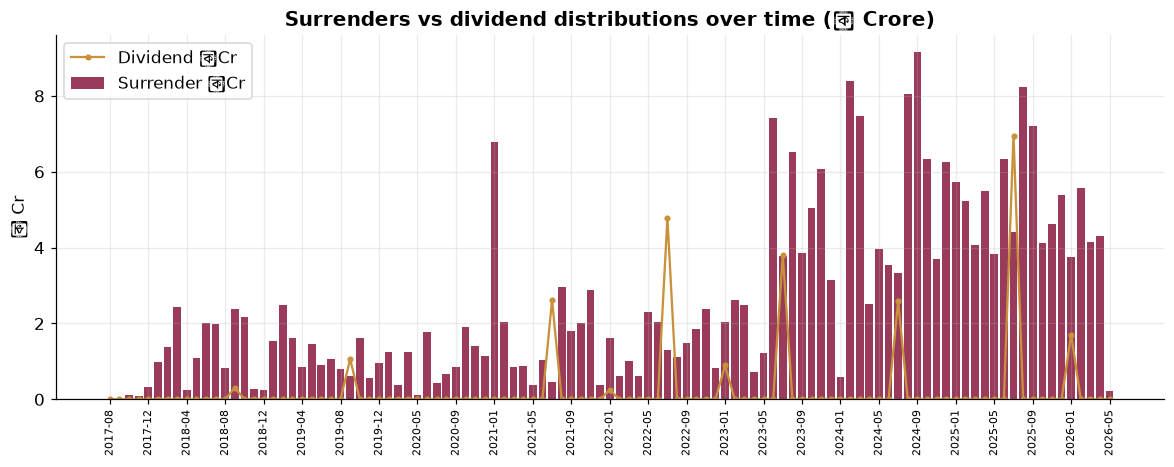

In [10]:
# Figure: monthly surrender value with dividend months highlighted
sur_m = sur.groupby('ym').amount.sum()
div_m = tx2[tx2.transaction_type=='Dividend'].groupby('ym').amount.sum()
idx = sorted(set(sur_m.index)|set(div_m.index))
fig, ax = plt.subplots(figsize=(13,4.3))
xs=np.arange(len(idx))
ax.bar(xs, [sur_m.get(i,0)/1e7 for i in idx], color='#9A3B5B', label='Surrender ৳Cr')
ax.plot(xs, [div_m.get(i,0)/1e7 for i in idx], color='#C9913B', marker='o', ms=3, lw=1.5, label='Dividend ৳Cr')
ax.set_xticks(xs[::4]); ax.set_xticklabels([idx[i] for i in range(0,len(idx),4)], rotation=90, fontsize=7)
ax.set_title('Surrenders vs dividend distributions over time (৳ Crore)'); ax.set_ylabel('৳ Cr'); ax.legend()
C.savefig(fig, SEC, '06_surrender_vs_dividend'); plt.show()

## 1.5 Composite fund ranking + recommendations
No single metric ranks a fund. We build a transparent composite from five min-max-normalised pillars, **weighted by what protects AUM**:

| Pillar | Weight | Why |
|---|---|---|
| Net flow (value) | 0.30 | Direct AUM growth/leakage in Taka — the bottom line |
| 36-mo cohort survival | 0.25 | Durable retention beats one-off sign-ups |
| SIP persistency | 0.20 | The recurring asset; engagement of the base |
| AUM scale (book) | 0.15 | Bigger book = more to defend / leverage |
| Low strict-churn | 0.10 | Penalise leakage directly |

Weights favour *durable growth* over raw size; justified above and logged in `decisions_log.md`.

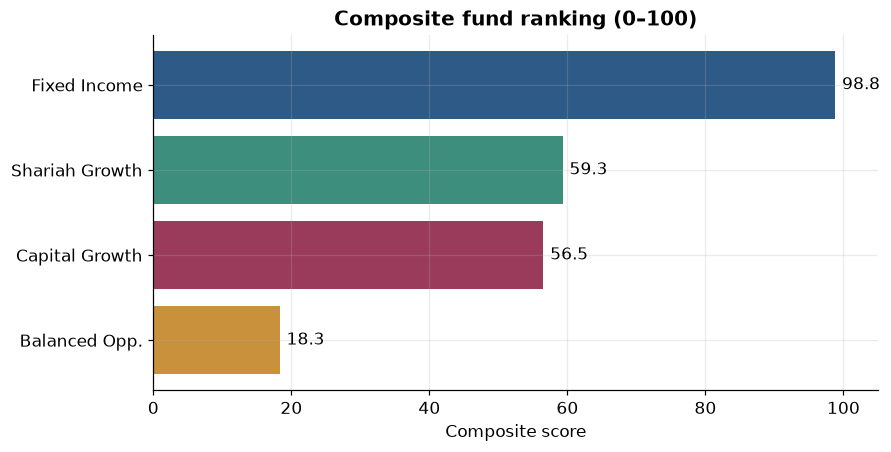

,net_flow_value,aum_book,churn_strict,surv_36m,persistency,composite_score,rank
fund,,,,,,,
Apex Fixed Income Fund,8.173081e+08,9.920891e+08,0.160,0.772,0.884,98.8,1
Apex Shariah Growth Fund,7.430865e+08,7.865763e+08,0.375,0.526,0.886,59.3,2
Apex Capital Growth Fund,6.808453e+08,8.708062e+08,0.472,0.542,0.886,56.5,3
Apex Balanced Opportunity Fund,2.513983e+08,3.666688e+08,0.337,0.663,0.842,18.3,4


In [11]:
def mm(s):
    s=s.astype(float); rng=s.max()-s.min()
    return (s-s.min())/rng if rng>0 else s*0+0.5
rank = scorecard[['net_flow_value','aum_book','churn_strict']].copy()
rank['surv_36m'] = fund_surv_tbl['surv_36m']
rank['persistency'] = pers_by_fund['weighted_persistency']
W = dict(net_flow_value=0.30, surv_36m=0.25, persistency=0.20, aum_book=0.15, low_churn=0.10)
score = (mm(rank.net_flow_value)*W['net_flow_value'] + mm(rank.surv_36m)*W['surv_36m']
        + mm(rank.persistency)*W['persistency'] + mm(rank.aum_book)*W['aum_book']
        + mm(1-rank.churn_strict)*W['low_churn'])
rank['composite_score'] = (score*100).round(1)
rank = rank.sort_values('composite_score', ascending=False)
rank['rank'] = range(1,len(rank)+1)
C.save_table(rank, SEC, 'fund_composite_ranking')
metrics['fund_ranking'] = rank.reset_index().to_dict('records')

fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.barh([SHORT[f] for f in rank.index][::-1], rank.composite_score[::-1],
        color=[COL[f] for f in rank.index][::-1])
for i,(f,v) in enumerate(zip(rank.index[::-1], rank.composite_score[::-1])): ax.text(v+1,i,f'{v}',va='center')
ax.set_xlim(0,105); ax.set_title('Composite fund ranking (0–100)'); ax.set_xlabel('Composite score')
C.savefig(fig, SEC, '07_fund_ranking'); plt.show()
rank.round(3)

In [12]:
C.dump_metrics(SEC, metrics)
print('Section 1 metrics persisted ->', (C.ANALYSIS/SEC/'_metrics.json'))
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 1 metrics persisted -> D:\GitHub\apex\analysis\section1\_metrics.json
figures: ['01_fund_scorecard.png', '02_sip_persistency_decay.png', '03_sip_persistency_vintage.png', '04_cohort_survival_km.png', '05_cohort_survival_by_fund.png', '06_surrender_vs_dividend.png', '07_fund_ranking.png']
tables : ['book_multiple_by_fund.csv', 'cohort_survival_by_fund.csv', 'cohort_survival_km.csv', 'fund_composite_ranking.csv', 'fund_scorecard.csv', 'sip_persistency_by_fund.csv', 'sip_persistency_by_vintage.csv', 'sip_persistency_decay.csv']


## 1.6 Section-1 findings (each phrased as a Monday decision)
*(Headlines are written to `findings_log.md`; per-fund recommendations are generated from the computed scorecard + ranking in the cell above. See the composite table for the ordering and the persistency/survival tables for the leakage story.)*

- **Defend the leakiest fund, don't just grow the biggest.** Rank funds by 36-month survival × persistency, not by AUM — the largest book can be the fastest-leaking.
- **SIP persistency is the asset.** The decay curve shows where installments stop arriving; that month is where a save/win-back call should fire.
- **Surrenders cluster around dividend months** — pre-empt with a reinvestment offer before each distribution rather than reacting after redemptions.

> **Reminder:** all of the above is *flow/retention/engagement*, not investment return — there is no NAV series in the data.